In [ ]:
# Linear SVM on the Iris dataset
# Binary classification: Setosa vs Non-Setosa

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. Load the Iris dataset
# ---------------------------------------------------------
iris = datasets.load_iris()

X = iris.data[:, [0, 1]]  # Sepal length and sepal width
y = iris.target

# Convert to binary classification:
# Setosa (class 0) -> 1
# Non-Setosa (classes 1 and 2) -> 0
y_binary = np.where(y == 0, 1, 0)

In [3]:
print("Feature names:", iris.feature_names[:2])
print("Number of samples:", X.shape[0])
print("Class distribution:")
print("Setosa:", np.sum(y_binary == 1))
print("Non-Setosa:", np.sum(y_binary == 0))

Feature names: ['sepal length (cm)', 'sepal width (cm)']
Number of samples: 150
Class distribution:
Setosa: 50
Non-Setosa: 100


In [4]:
# 2. Split into training and testing data
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [5]:
# 3. Standardize the features
# ---------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# 4. Train Linear SVM
# ---------------------------------------------------------
svm_model = SVC(
    kernel="linear",
    C=1.0
)

svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
# 5. Evaluate the model
# ---------------------------------------------------------
y_pred = svm_model.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Setosa", "Setosa"]
))



Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

  Non-Setosa       0.95      1.00      0.98        20
      Setosa       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.98      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



In [9]:
# 6. Get decision boundary and margins
# ---------------------------------------------------------
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

print("\nWeight vector:", w)
print("Bias:", b)

# Decision boundary:
# w0*x + w1*y + b = 0
#
# Margin boundaries:
# w0*x + w1*y + b = +1
# w0*x + w1*y + b = -1

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

x_values = np.linspace(x_min, x_max, 200)

decision_boundary = -(w[0] * x_values + b) / w[1]
margin_positive = -(w[0] * x_values + b - 1) / w[1]
margin_negative = -(w[0] * x_values + b + 1) / w[1]


Weight vector: [-2.11605556  1.53255624]
Bias: -1.4446568562854267


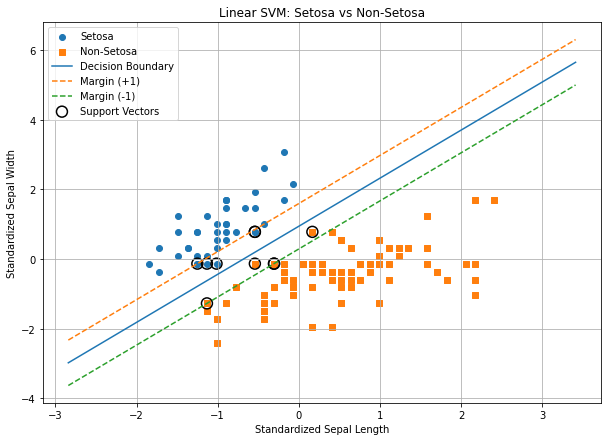

In [10]:
# 7. Visualize decision boundary and margins
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))

# Plot training samples
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    marker="o",
    label="Setosa"
)

plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    marker="s",
    label="Non-Setosa"
)

# Decision boundary
plt.plot(
    x_values,
    decision_boundary,
    label="Decision Boundary"
)

# Margins
plt.plot(
    x_values,
    margin_positive,
    "--",
    label="Margin (+1)"
)

plt.plot(
    x_values,
    margin_negative,
    "--",
    label="Margin (-1)"
)

# Highlight support vectors
plt.scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Sepal Width")
plt.title("Linear SVM: Setosa vs Non-Setosa")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# 8. Calculate the margin width
# ---------------------------------------------------------
margin_width = 2 / np.linalg.norm(w)

print("Margin width:", margin_width)
print("Number of support vectors:", len(svm_model.support_vectors_))

Margin width: 0.7654793870695655
Number of support vectors: 10
